In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [3]:
import statistics

In [4]:
# mean, median, mode
df = sns.load_dataset('tips')

In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
mean = np.mean(df['total_bill'])
print("Mean of total_bill is:", mean)

Mean of total_bill is: 19.78594262295082


In [7]:
median = np.median(df['total_bill'])
print("Median of total_bill is:", median)

Median of total_bill is: 17.795


In [8]:
mode = statistics.mode(df['total_bill'])
print("Mode of total_bill is:", mode)

Mode of total_bill is: 13.42


<Axes: ylabel='total_bill'>

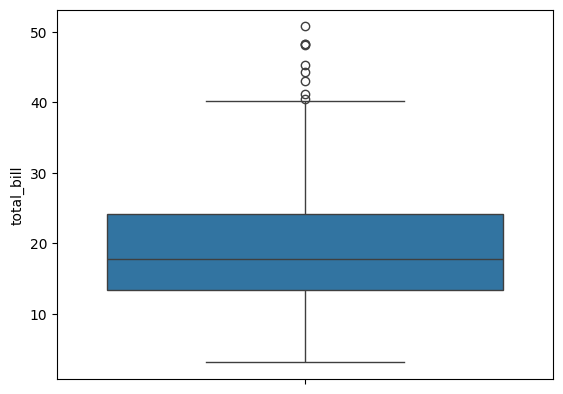

In [9]:
sns.boxplot(df['total_bill'])

<Axes: ylabel='tip'>

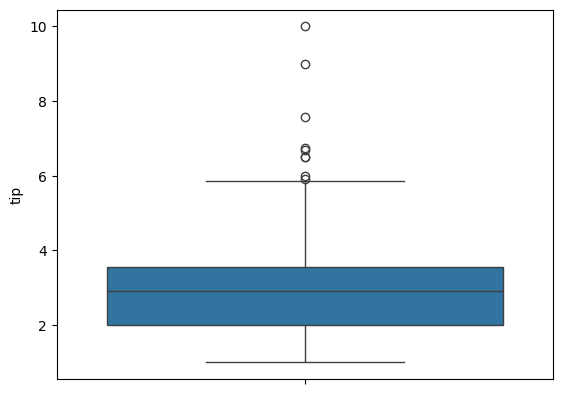

In [10]:
sns.boxplot(df["tip"])

<Axes: xlabel='total_bill', ylabel='Count'>

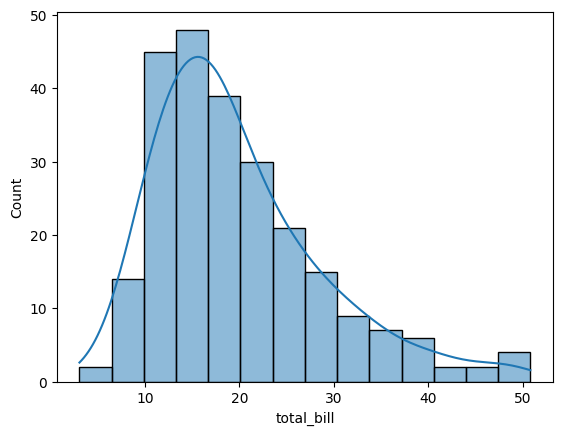

In [11]:
sns.histplot(df['total_bill'], kde=True) # this is not the normaly distributed

In [12]:
# lets try with the another data

df1 = sns.load_dataset('iris')

In [13]:
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_width', ylabel='Count'>

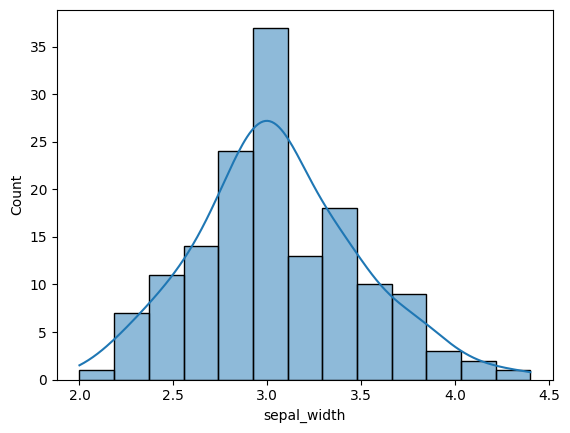

In [14]:
sns.histplot(df1['sepal_width'], kde=True)

<Axes: xlabel='count', ylabel='species'>

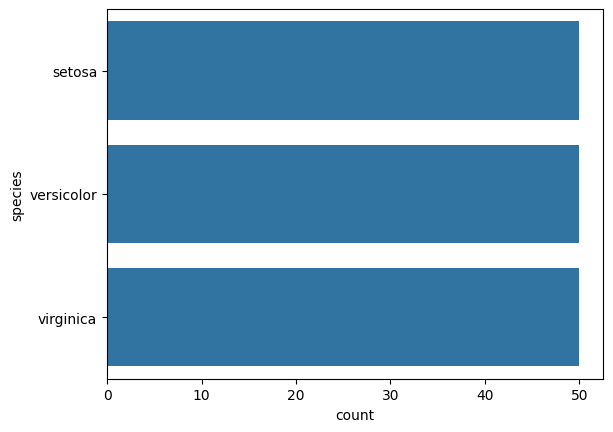

In [15]:
sns.countplot(df1['species'])

In [16]:
np.percentile(df1['sepal_length'], [25, 75])

array([5.1, 6.4])

outlier - After the 3rd standard deviation all the data is outliers

In [17]:
dataset = [11, 10, 12, 14, 12, 15, 14, 13, 15, 102, 12, 14, 17, 19, 107, 10, 13, 12, 14, 12, 108, 12, 11, 14, 13, 15, 10, 12, 10, 14, 13, 15, 10]


(array([30.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.]),
 array([ 10. ,  19.8,  29.6,  39.4,  49.2,  59. ,  68.8,  78.6,  88.4,
         98.2, 108. ]),
 <BarContainer object of 10 artists>)

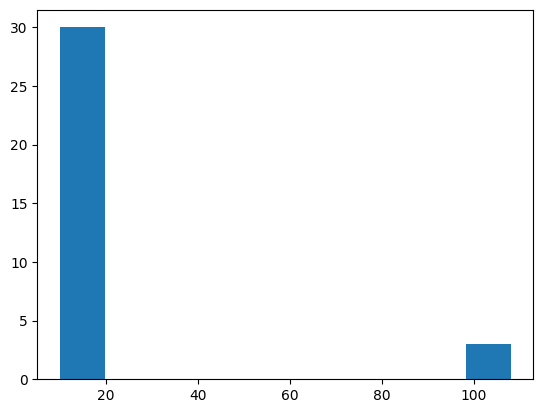

In [18]:
plt.hist(dataset)

In [19]:
outliers = []
def detect_outliers(data):
    threshold = 3 # this is 3rd standard deviation
    mean = np.mean(data)
    std = np.std(data)
    for i in data:
      z_score = (i-mean)/std
      if np.abs(z_score) > threshold:
        outliers.append(i)
    return outliers



In [20]:
detect_outliers(dataset)

[102, 107, 108]

# IQR
1. Sort the data
2. Calculate Q1 and Q3
3. Find IQR
   IQR = (Q3 - Q1)
4. Find the lower boundary = Q1 - (1.5 * IQR)
5. Find the upper boundary = Q1 + (1.5 * IQR)

In [21]:
# Sort the data
sorted_data = sorted(dataset)
print(sorted_data)

[10, 10, 10, 10, 10, 11, 11, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 17, 19, 102, 107, 108]


In [22]:
# Calculate Q1 and Q3

Q1 = np.percentile(dataset, 25)
Q3 = np.percentile(dataset, 75)
print(Q1, Q3)

12.0 15.0


In [23]:
# Find IQR IQR = (Q3 - Q1)
IQR = Q3 - Q1
print(IQR)

3.0


In [24]:
# Find the lower boundary = Q1 - (1.5 * IQR)
lower_boundary = Q1 - (1.5 * IQR)
print(lower_boundary)

7.5


In [25]:
# Find the upper boundary = Q1 + (1.5 * IQR)
upper_boundary = Q3 + (1.5 * IQR)
print(upper_boundary)

19.5


In [26]:
# data without outliers
data_without_outliers = [i for i in dataset if i >= lower_boundary and i <= upper_boundary]
print(data_without_outliers)

[11, 10, 12, 14, 12, 15, 14, 13, 15, 12, 14, 17, 19, 10, 13, 12, 14, 12, 12, 11, 14, 13, 15, 10, 12, 10, 14, 13, 15, 10]


<Axes: >

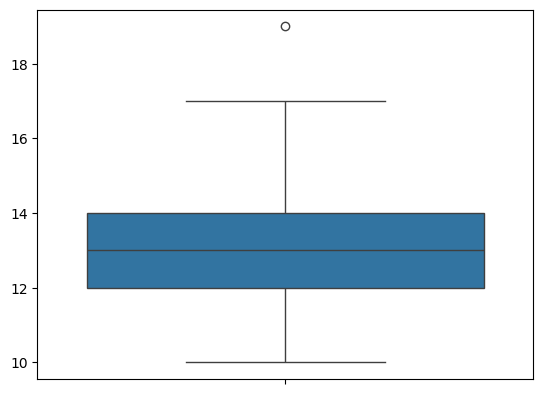

In [27]:
sns.boxplot(data_without_outliers)

<Axes: >

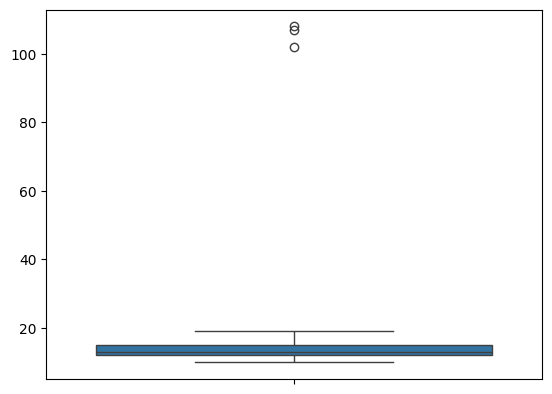

In [28]:
sns.boxplot(dataset) # with outliers

# Standarization




In [29]:
df = pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [30]:
df.drop(['User ID', 'Gender'], axis=1, inplace=True)

In [31]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


# Train test split


In [32]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

StandardScaler use the formula that is (Xi - mean)/std

In [33]:
# learn the model form the teaining data but we tranform the both data training and testing
# one problem that take a dataframe and give the numpy array so we have to convert

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # created object

scaler.fit(X_train) # calculate the mean of both the columns and

X_train_scaled = scaler.fit_transform(X_train) # use the formula here
X_test_scaled = scaler.transform(X_test)

In [34]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [35]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [36]:
# convert inti data frame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [37]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [38]:
# before the standardization

np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [39]:
# After the standardization

np.round(X_train_scaled.describe(), 1)

# so in this data set the mean is 0 and std is 1

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


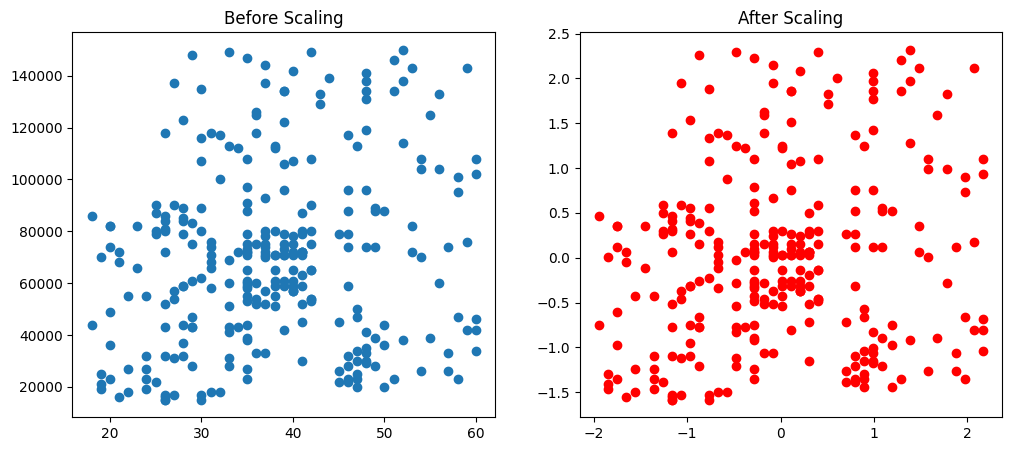

In [40]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

# Normalization

In [41]:
df2 = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df2.columns=['Class label', 'Alcohol', 'Malic acid']

In [42]:
df2

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df2.drop('Class label', axis=1),
                                                    df2['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() # created object

scaler.fit(X_train) # calculation

X_train_scaled = scaler.fit_transform(X_train) # use the formula here
X_test_scaled = scaler.transform(X_test)

In [45]:

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [46]:
np.round(X_train.describe(), 1)
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [47]:

np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


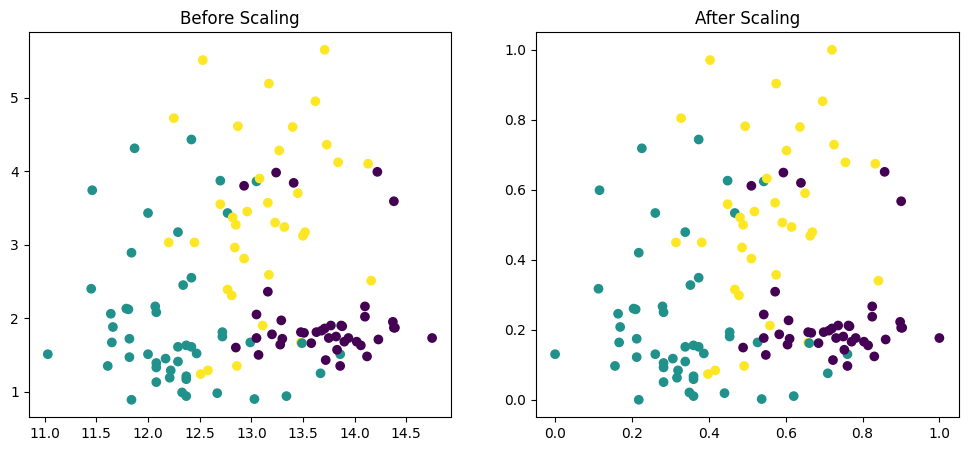

In [48]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

# Z Test

In [49]:
from statsmodels.stats.weightstats import ztest

In [50]:
# physics score
population_mean_score = 75

In [51]:
# sample size n > 30
scores = np.random.randint(65,95, 30)
scores

array([81, 92, 67, 80, 78, 90, 93, 69, 66, 89, 91, 77, 89, 70, 69, 86, 73,
       68, 86, 65, 88, 67, 82, 87, 67, 81, 68, 73, 69, 86])

In [52]:
# apply z test

z_score, p_value = ztest(scores, value = population_mean_score)

print("Z-score:", z_score)
print("P-value:", p_value)

Z-score: 1.8634251709855332
P-value: 0.062402471381414984


In [53]:
# Significance value

alpha = 0.05

In [54]:
if p_value < alpha:
  print("Reject the null hypothesis, as the p-value is less than the significance level")
else:
  print("Accept the null hypothesis, as the p-value is greater than the significance level")


Accept the null hypothesis, as the p-value is greater than the significance level


# T test

we try to check that weather the is a different between sample mean and the puopulation mean

H0 = there is no diffeernt

H1 = there is different

In [55]:
ages = np.random.randint(10, 70, 32)
ages

array([52, 57, 63, 66, 69, 69, 60, 53, 53, 14, 61, 21, 39, 13, 59, 59, 68,
       21, 51, 63, 23, 30, 24, 32, 26, 55, 13, 50, 17, 17, 26, 14])

In [56]:
ages_mean = np.mean(ages)
print(ages_mean)

41.8125


In [57]:
# take sample form population

sample_size = 10
age_sample = np.random.choice(ages, sample_size)
age_sample

array([26, 63, 63, 60, 39, 26, 23, 66, 17, 52])

In [58]:
from scipy.stats import ttest_1samp

In [59]:
ttest, p_value = ttest_1samp(age_sample, ages_mean )
print("T-test:", ttest)
print("P-value:", p_value)

T-test: 0.27591526395401905
P-value: 0.7888439663107712


In [60]:
if p_value < alpha:
  print("Reject the null hypothesis, as the p-value is less than the significance level")
else:
  print("Accept the null hypothesis, as the p-value is greater than the significance level")

Accept the null hypothesis, as the p-value is greater than the significance level


# Chi Square test

H0 = there is no relation between 2 categorical variable  

H1 = there is relation between 2 categorical variable  

In [61]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [62]:
dataset_table = pd.crosstab(df['sex'], df['smoker'])
dataset_table

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [63]:
observed_values = dataset_table.values
print("Observed Values: \n", observed_values)

Observed Values: 
 [[60 97]
 [33 54]]


In [64]:
import scipy.stats as stats
val = stats.chi2_contingency(dataset_table)
val

Chi2ContingencyResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), dof=1, expected_freq=array([[59.84016393, 97.15983607],
       [33.15983607, 53.84016393]]))

In [65]:
expected_values = val[3]
expected_values

array([[59.84016393, 97.15983607],
       [33.15983607, 53.84016393]])

In [66]:
no_of_rows = len(dataset_table.iloc[0:2, 0])
no_of_columns = len(dataset_table.iloc[0, 0:2])
ddof = val[2]
print("Degree of Freedom:", ddof)
# alpha = 0.05

Degree of Freedom: 1


In [67]:
from scipy.stats import chi2
chi_square = sum([(o-e)**2./e for o, e in zip(observed_values, expected_values)])
chi_square_statistic = chi_square[0] + chi_square[1]
print("chi-square statistic:", chi_square_statistic)

chi-square statistic: 0.001934818536627623


In [68]:
critical_value = chi2.ppf(q=1-alpha, df=ddof)
print('critical_value:', critical_value)

critical_value: 3.841458820694124


In [69]:
if chi_square_statistic >= critical_value:
  print("Reject the null hypothesis, There is a relation between 2 categorical variables")
else:
  print("Accept the null hypothesis, There is no relation between 2 categorical variables")

Accept the null hypothesis, There is no relation between 2 categorical variables


# F Test or ANOVA

In [70]:
# These are the scores (from 1 to 10) given by each kid.
chocolate_scores = [8, 9, 7, 8, 10, 9, 7]
vanilla_scores =   [6, 7, 8, 7, 6, 8, 7]
# strawberry_scores= [3, 4, 2, 3, 5, 4, 2]
strawberry_scores= [6, 8, 6, 7, 10, 7, 9]

# one-way ANOVA test
# The f_oneway function takes each group's data as an argument.
f_statistic, p_value = stats.f_oneway(chocolate_scores, vanilla_scores, strawberry_scores)

# Print the results
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# costruct the conclusion
alpha = 0.05  # This is our significance level

if p_value < alpha:
    print("The p-value is less than 0.05, so the result is statistically significant.")
    print("We can conclude that there is a real difference in the average scores of the ice cream flavors.")
else:
    print("The p-value is greater than 0.05, so the result is not statistically significant.")
    print("We cannot conclude that there is a difference in the average scores.")

F-statistic: 2.079545454545455
P-value: 0.1539873669615178
The p-value is greater than 0.05, so the result is not statistically significant.
We cannot conclude that there is a difference in the average scores.


What is Z-test?

Z-test is a statistical test used to compare two population mean. It is conducted when:

Sample size (n) ≥ 30

Population standard deviation (σ) is known

Z-Score

A Z-score measures exactly how many standard deviations above or below the mean a data point is.

H0 = there is no difference

H1 = there is difference

In [77]:
#data = [88, 92, 94, 94, 96, 97, 97, 97, 99, 99, 105, 109, 109, 109, 110, 112, 112, 113, 114, 115]
data = [8, 9, 4, 4, 6, 7, 97, 97, 99, 99, 105, 109, 109, 109, 110, 112, 112, 113, 114, 115]

z_stat, p_value = ztest(data, value=100)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -2.1651181661663275
P-value: 0.030378637124401465


In [78]:
if p_value < alpha:
  print("Reject the null hypothesis, as the p-value is less than the significance level")
else:
  print("Accept the null hypothesis, as the p-value is greater than the significance level")


Reject the null hypothesis, as the p-value is less than the significance level
